# Beverton-Holt Recruitment Model

The Beverton-Holt model describes the relationship between Spawning Stock Biomass ($S$) and the number of Recruits ($R$). It assumes that juvenile survival decreases as population density increases (e.g., due to competition for limited food or shelter).

### 1. The Mathematical Equation
$$R = \frac{\alpha S}{1 + \beta S}$$

Where:
* $R$: Number of recruits (offspring).
* $S$: Spawning stock biomass (parents).
* $\alpha$: Maximum recruitment rate per spawner (initial slope at $S \approx 0$).
* $\beta$: Density-dependent parameter (controls how quickly the curve flattens).

### 2. Key Features
* **Asymptotic:** As $S \to \infty$, the number of recruits approaches a maximum limit $R_{max} = \frac{\alpha}{\beta}$.
* **Stability:** Unlike the Ricker model, the Beverton-Holt curve never bends downwards. It does not exhibit chaos or oscillations; the population typically approaches the carrying capacity smoothly.

### 3. Replacement Line
For a population to persist, recruitment must exceed natural mortality. We often plot a "Replacement Line" ($R = S$) to find the equilibrium point where the population sustains itself.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')

def beverton_holt(S, alpha, beta):
    """
    R = (alpha * S) / (1 + beta * S)
    """
    return (alpha * S) / (1 + beta * S)

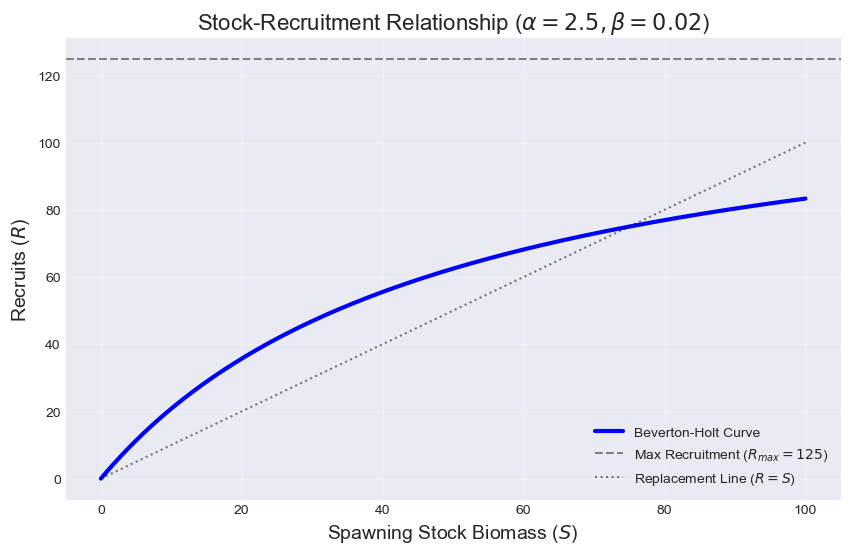

In [2]:
# --- Parameters ---
S = np.linspace(0, 100, 200) # Range of Spawning Stock
alpha = 2.5                  # Productivity (recruits per spawner)
beta = 0.02                  # Density dependence

# Calculate Recruitment
R = beverton_holt(S, alpha, beta)
R_max = alpha / beta

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 6))

# 1. The Beverton-Holt Curve
ax.plot(S, R, 'b-', linewidth=3, label='Beverton-Holt Curve')

# 2. Asymptote
ax.axhline(R_max, color='gray', linestyle='--', label=f'Max Recruitment ($R_{{max}}={R_max:.0f}$)')

# 3. Replacement Line (1:1)
# Intersection is the Equilibrium (Carrying Capacity)
ax.plot(S, S, 'k:', alpha=0.5, label='Replacement Line ($R=S$)')

ax.set_title(f'Stock-Recruitment Relationship ($\\alpha={alpha}, \\beta={beta}$)', fontsize=16)
ax.set_xlabel('Spawning Stock Biomass ($S$)', fontsize=14)
ax.set_ylabel('Recruits ($R$)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

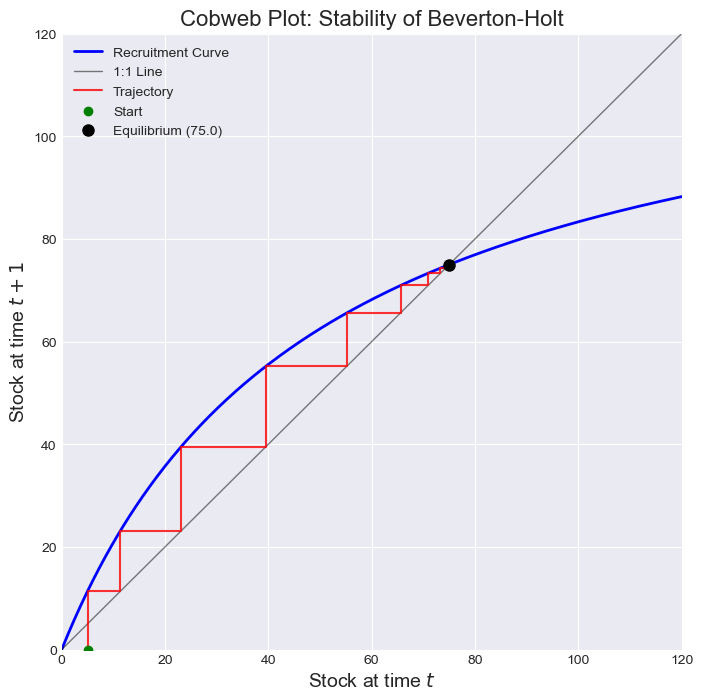

In [3]:
def plot_cobweb_bh(alpha, beta, n_generations=20):
    # Setup the function curve
    S_max = 120
    x = np.linspace(0, S_max, 500)
    y = beverton_holt(x, alpha, beta)
    
    # Calculate trajectory
    N_t = 5 # Start with very low population
    path_x = [N_t]
    path_y = [0]
    
    for _ in range(n_generations):
        # 1. Go up to the curve
        N_next = beverton_holt(N_t, alpha, beta)
        path_x.extend([N_t, N_t])
        path_y.extend([N_t, N_next])
        
        # 2. Go sideways to the 1:1 line
        path_x.extend([N_next])
        path_y.extend([N_next])
        
        N_t = N_next
        
    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Background curves
    ax.plot(x, y, 'b-', linewidth=2, label='Recruitment Curve')
    ax.plot(x, x, 'k-', linewidth=1, alpha=0.5, label='1:1 Line')
    
    # Cobweb Path
    ax.plot(path_x, path_y, 'r-', linewidth=1.5, alpha=0.8, label='Trajectory')
    ax.scatter(path_x[0], path_y[0], color='green', zorder=5, label='Start')
    
    # Annotate Equilibrium
    equil = (alpha - 1) / beta
    ax.plot(equil, equil, 'ko', markersize=8, label=f'Equilibrium ({equil:.1f})')
    
    ax.set_title('Cobweb Plot: Stability of Beverton-Holt', fontsize=16)
    ax.set_xlabel('Stock at time $t$', fontsize=14)
    ax.set_ylabel('Stock at time $t+1$', fontsize=14)
    ax.legend()
    ax.set_xlim(0, S_max)
    ax.set_ylim(0, S_max)
    
    plt.show()

# Run the plot
plot_cobweb_bh(alpha=2.5, beta=0.02)

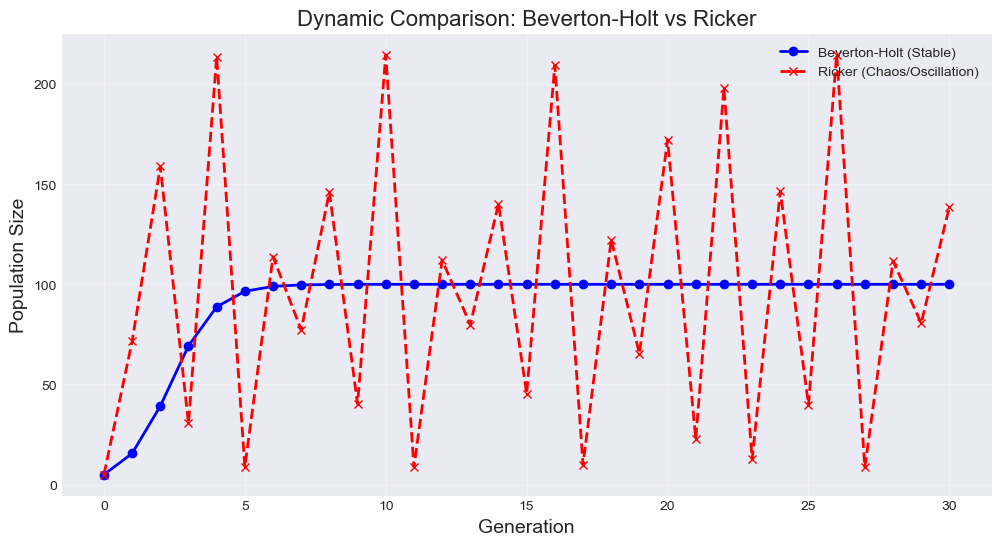

In [4]:
def ricker_model(S, r, K):
    """Ricker map: S * exp(r * (1 - S/K))"""
    return S * np.exp(r * (1 - S / K))

# --- Parameters ---
generations = 30
N0 = 5

# Beverton-Holt Params
alpha_bh = 3.5
beta_bh = 0.025

# Ricker Params (High growth rate to show instability)
r_ricker = 2.8 
K_ricker = 100

# --- Simulation ---
bh_pop = [N0]
ricker_pop = [N0]

for t in range(generations):
    # Beverton Holt Step
    next_bh = beverton_holt(bh_pop[-1], alpha_bh, beta_bh)
    bh_pop.append(next_bh)
    
    # Ricker Step
    next_rk = ricker_model(ricker_pop[-1], r_ricker, K_ricker)
    ricker_pop.append(next_rk)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(bh_pop, 'b-o', linewidth=2, label='Beverton-Holt (Stable)')
ax.plot(ricker_pop, 'r--x', linewidth=2, label='Ricker (Chaos/Oscillation)')

ax.set_title('Dynamic Comparison: Beverton-Holt vs Ricker', fontsize=16)
ax.set_xlabel('Generation', fontsize=14)
ax.set_ylabel('Population Size', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()